In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re
import warnings

warnings.filterwarnings('ignore')

In [11]:
# configuration
'''
    requirements for trade logs - 
        1. have them named in ideal format of day*.csv
        2. have a PnL column
'''
LOG_DIR = "./trade_logs"
ITERATIONS = 2000
DROP_PCT = 0.20

In [12]:
def load_and_audit_data(path):
    all_files = glob.glob(os.path.join(path, "*.[cC][sS][vV]"))
    
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {path}")
        
    daily_data = [] 
    seen_days = set()

    for filename in all_files:
        basename = os.path.basename(filename)
        match = re.search(r'day[\s_-]*(\d+)', basename, re.IGNORECASE)
        
        if match:
            day_idx = int(match.group(1))
            try:
                df = pd.read_csv(filename)
                col_map = {c.lower(): c for c in df.columns}
                if 'pnl' in col_map:
                    pnl_values = df[col_map['pnl']].values
                    daily_data.append((day_idx, pnl_values))
                    seen_days.add(day_idx)
            except Exception:
                pass

    daily_data.sort(key=lambda x: x[0])
    
    if not daily_data:
        raise ValueError("No valid data found.")

    min_day = daily_data[0][0]
    max_day = daily_data[-1][0]
    days_found = len(daily_data)
    
    print(f"Found {days_found} files. Index Range: {min_day} to {max_day}.")
    
    return daily_data, min_day, max_day

In [18]:
def calculate_sharpe(daily_data):
    daily_returns_list = [np.sum(trades) for day_idx, trades in daily_data]
    
    daily_returns = np.array(daily_returns_list)
    
    if len(daily_returns) == 0:
        return 0.0
    
    mean_daily = np.mean(daily_returns)
    std_daily = np.std(daily_returns)
    
    if std_daily != 0:
        sharpe = (mean_daily / std_daily) * np.sqrt(252)
    else:
        sharpe = 0.0

    return sharpe
def calculate_sortino(daily_pnl_sums, risk_free_rate=0.0):
    daily_returns = np.array(daily_pnl_sums)

    if len(daily_returns) < 2:
        return 0.0

    downside = daily_returns[daily_returns < risk_free_rate]

    if len(downside) == 0:
        return np.inf  # no downside volatility

    downside_std = np.std(downside, ddof=1)
    mean_excess = np.mean(daily_returns - risk_free_rate)

    # annualised Sortino
    return (mean_excess / downside_std) * np.sqrt(252)

In [19]:
# stress tests
def get_max_drawdown(returns_array):
    if len(returns_array) == 0: return 0.0
    equity_curve = np.cumsum(np.insert(returns_array, 0, 0))
    hwm = np.maximum.accumulate(equity_curve)
    return np.max(hwm - equity_curve)

def stress_connectivity(trades_arr, iterations, drop_pct):
    n_keep = int(len(trades_arr) * (1 - drop_pct))
    sims = [np.sum(np.random.choice(trades_arr, n_keep, replace=False))*100 for _ in range(iterations)]
    
    original_ret = np.sum(trades_arr) * 100
    avg_sim_ret = np.mean(sims)
    expected_ret = original_ret * (1 - drop_pct)

    plt.figure(figsize=(10, 5))
    sns.histplot(sims, kde=True, color='purple', alpha=0.4, edgecolor='purple')
    
    # Lines
    plt.axvline(original_ret, color='green', linewidth=2, linestyle='-', label=f'Original: {original_ret:.2f}%')
    plt.axvline(avg_sim_ret, color='purple', linewidth=2, linestyle='--', label=f'Avg Sim: {avg_sim_ret:.2f}%')
    plt.axvline(expected_ret, color='black', linewidth=2, linestyle=':', label=f'Expected: {expected_ret:.2f}%')
    
    # Labels & Title
    plt.title(f"Connectivity Test (Dropping {int(drop_pct*100)}% of Trades)", fontsize=12)
    plt.xlabel("Total Net Return (%)", fontsize=10)
    plt.ylabel("Frequency (Iterations)", fontsize=10)
    plt.grid(True, alpha=0.25, linestyle='--')
    plt.legend(loc='upper left')

def stress_shuffle_trades(trades_arr, iterations):
    actual_dd = get_max_drawdown(trades_arr) * 100
    sims = []
    temp = trades_arr.copy()
    
    # Run Simulation
    for _ in range(iterations):
        np.random.shuffle(temp)
        sims.append(get_max_drawdown(temp) * 100)
    
    risk_95 = np.percentile(sims, 95)
    avg_dd = np.mean(sims)
    
    plt.figure(figsize=(10, 5))
    sns.histplot(sims, kde=True, color='orange', alpha=0.5, edgecolor='orange')
    
    # Lines
    plt.axvline(actual_dd, color='green', linewidth=2, label=f'Actual DD: {actual_dd:.2f}%')
    plt.axvline(risk_95, color='red', linestyle='--', linewidth=2, label=f'95% VaR DD: {risk_95:.2f}%')
    plt.axvline(avg_dd, color='blue', linestyle='-.', linewidth=2, label=f'Avg DD: {avg_dd:.2f}%')
    
    # Labels & Title
    plt.title(f"Monte Carlo (Shuffled Trades - {iterations} iter)", fontsize=12)
    plt.xlabel("Max Drawdown Depth (%)", fontsize=10)
    plt.ylabel("Frequency (Iterations)", fontsize=10)
    plt.grid(True, alpha=0.25, linestyle='--')
    plt.legend(loc='upper right')

def stress_shuffle_days(daily_sequences, original_dd, iterations):
    sims = []
    idx = np.arange(len(daily_sequences))
    
    # Run Simulation
    for _ in range(iterations):
        np.random.shuffle(idx)
        shuffled = np.concatenate([daily_sequences[i] for i in idx])
        sims.append(get_max_drawdown(shuffled) * 100)
    
    risk_95 = np.percentile(sims, 95)
    avg_dd = np.mean(sims)
    
    plt.figure(figsize=(10, 5))
    sns.histplot(sims, kde=True, color='dodgerblue', alpha=0.5, edgecolor='#1e90ff')
    
    # Lines
    plt.axvline(original_dd, color='green', linewidth=2, label=f'Actual DD: {original_dd:.2f}%')
    plt.axvline(risk_95, color='orange', linestyle='--', linewidth=2, label=f'95% VaR DD: {risk_95:.2f}%')
    plt.axvline(avg_dd, color='blue', linestyle='-.', linewidth=2, label=f'Avg DD: {avg_dd:.2f}%')
    
    # Labels & Title
    plt.title(f"Monte Carlo (Shuffled Days - {iterations} iter)", fontsize=12)
    plt.xlabel("Max Drawdown Depth (%)", fontsize=10)
    plt.ylabel("Frequency (Iterations)", fontsize=10)
    plt.grid(True, alpha=0.25, linestyle='--')
    plt.legend(loc='upper right')

In [20]:
def stress_monte_carlo_gaussian(daily_returns, current_dd, actual_total_ret, iterations):
    """
    Simulates N synthetic equity curves via GBM.
    Plots both Projected Risk (Drawdown) and Projected Reward (Total Return).
    """
    # 1. Statistics
    mu = np.mean(daily_returns)
    sigma = np.std(daily_returns)
    n_days = len(daily_returns)
    
    # Z ~ N(0, 1)
    Z = np.random.normal(0, 1, (iterations, n_days))
    sim_daily_steps = mu + sigma * Z
    
    # Cumulative Sum to get Equity Curves
    sim_curves = np.cumsum(sim_daily_steps, axis=1)
    
    # max dd
    hwm = np.maximum.accumulate(sim_curves, axis=1)
    drawdowns = hwm - sim_curves
    sim_mdds = np.max(drawdowns, axis=1) * 100 
    
    # The last value of each curve is the final total return
    sim_total_rets = sim_curves[:, -1] * 100    

    # Drawdown Stats
    dd_95 = np.percentile(sim_mdds, 95)
    dd_avg = np.mean(sim_mdds)
    
    # Return Stats
    ret_avg = np.mean(sim_total_rets)
    ret_median = np.median(sim_total_rets)
    ret_05 = np.percentile(sim_total_rets, 5)   # Worst 5% outcome
    ret_95 = np.percentile(sim_total_rets, 95)  # Best 5% outcome

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # PLOT 1: Max Drawdown (Risk)
    sns.histplot(sim_mdds, kde=True, color='teal', alpha=0.5, edgecolor='teal', ax=ax1)
    ax1.axvline(current_dd, color='green', linewidth=2, label=f'Actual: {current_dd:.2f}%')
    ax1.axvline(dd_95, color='red', linestyle='--', linewidth=2, label=f'95% VaR: {dd_95:.2f}%')
    ax1.axvline(dd_avg, color='blue', linestyle='-.', linewidth=2, label=f'Avg Sim: {dd_avg:.2f}%')
    ax1.set_title(f"Predicted Max Drawdown (Risk)", fontsize=12)
    ax1.set_xlabel("Max Drawdown (%)")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.25, linestyle='--')

    # PLOT 2: Total Return (Reward)
    sns.histplot(sim_total_rets, kde=True, color='purple', alpha=0.5, edgecolor='purple', ax=ax2)
    
    # Lines for Returns
    actual_ret_pct = actual_total_ret * 100 
    
    ax2.axvline(actual_ret_pct, color='green', linewidth=2, label=f'Actual: {actual_ret_pct:.2f}%')
    ax2.axvline(ret_avg, color='blue', linestyle='-.', linewidth=2, label=f'Avg Sim: {ret_avg:.2f}%')
    ax2.axvline(ret_05, color='red', linestyle=':', linewidth=2, label=f'Worst 5%: {ret_05:.2f}%')
    ax2.axvline(ret_95, color='orange', linestyle=':', linewidth=2, label=f'Best 5%: {ret_95:.2f}%')
    
    ax2.set_title(f"Predicted Total Return (Reward)", fontsize=12)
    ax2.set_xlabel("Total Return (%)")
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.25, linestyle='--')

    plt.tight_layout()

Found 510 files. Index Range: 0 to 509.
 STRATEGY REPORT
Net Return:          54.50%
Annualised Return:   26.93%
Max Drawdown:        3.12%
----------------------------------------
Sharpe Ratio:        2.28
Calmar Ratio:        8.63
Sortino Ratio:       5.11
Win Rate:            62.50%
Profit Factor:       2.60

Running Stress Tests...


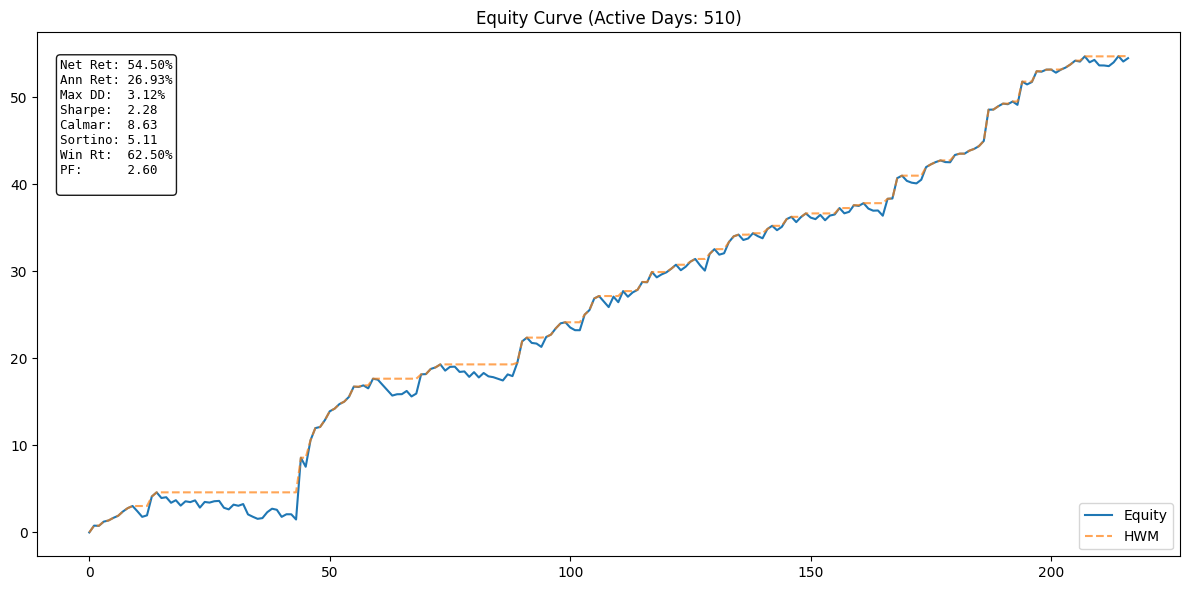

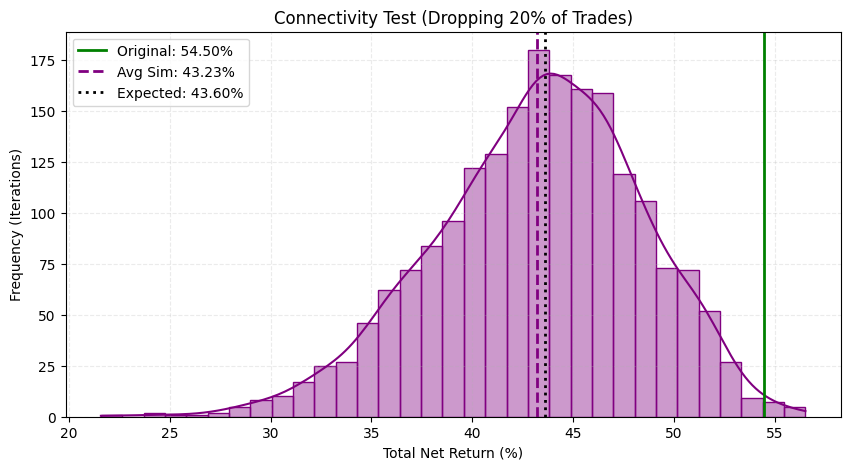

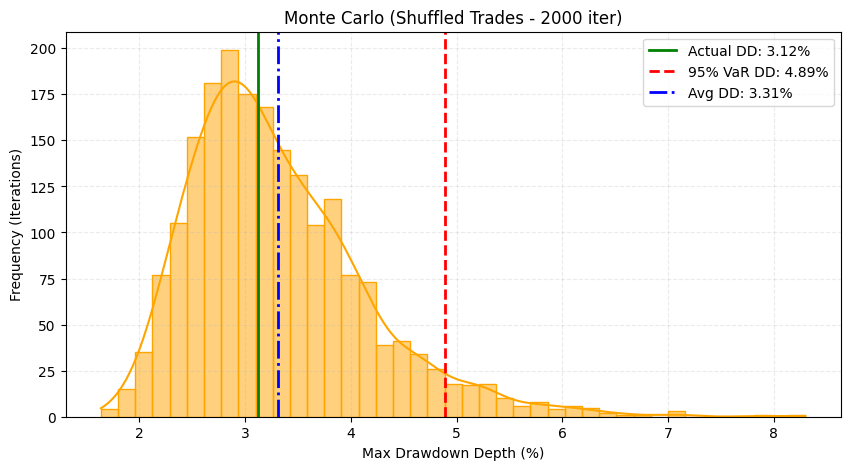

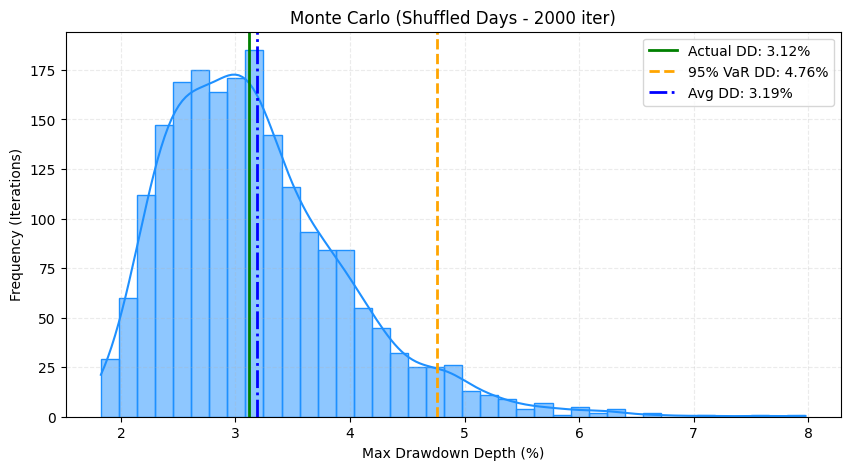

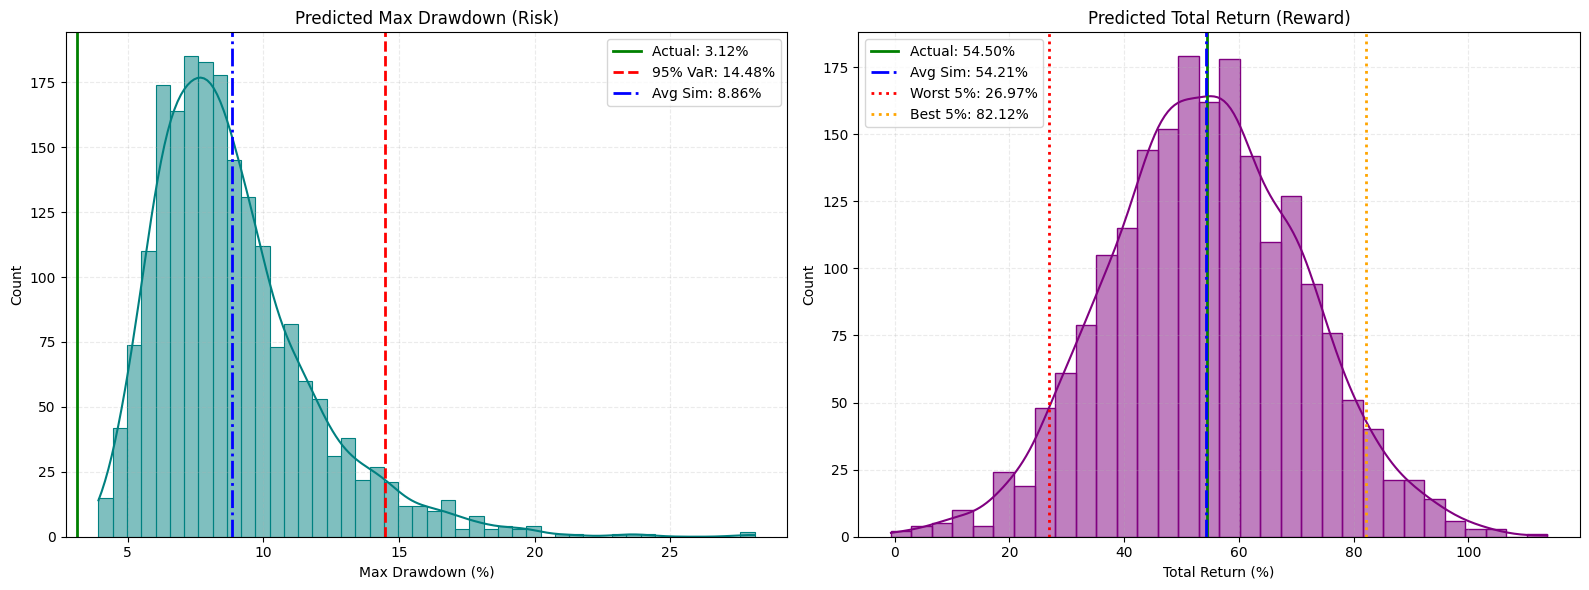

In [23]:
if __name__ == "__main__":
    try:
        daily_data, min_day, max_day = load_and_audit_data(LOG_DIR)

        daily_sequences = [x[1] for x in daily_data]
        all_trades = np.concatenate(daily_sequences)
        daily_pnl_sums = np.array([np.sum(day) for day in daily_sequences])

        valid_trades = all_trades[all_trades != 0]

        if len(valid_trades) == 0:
            print("No valid trades found.")
            exit()

        if len(valid_trades) < 20:
            print("Not enough trades for analysis.")
            exit()

        win_rate = np.mean(valid_trades > 0) * 100

        gross_profit = np.sum(valid_trades[valid_trades > 0])
        gross_loss = -np.sum(valid_trades[valid_trades < 0])

        profit_factor = (
            gross_profit / gross_loss if gross_loss > 0 else np.inf
        )

        total_ret = np.sum(valid_trades)
        max_dd = get_max_drawdown(valid_trades) * 100

        duration_units = len(daily_data)
        annualised = total_ret * (252 / duration_units) if duration_units > 0 else 0.0

        calmar = annualised / (max_dd / 100) if max_dd != 0 else 0.0
        sharpe = calculate_sharpe(daily_data)
        sortino = calculate_sortino(daily_pnl_sums)
        
        print(" STRATEGY REPORT")
        print(f"Net Return:          {total_ret*100:.2f}%")
        print(f"Annualised Return:   {annualised*100:.2f}%")
        print(f"Max Drawdown:        {max_dd:.2f}%")
        print("-" * 40)
        print(f"Sharpe Ratio:        {sharpe:.2f}")
        print(f"Calmar Ratio:        {calmar:.2f}")
        print(f"Sortino Ratio:       {sortino:.2f}")
        print(f"Win Rate:            {win_rate:.2f}%")
        print(f"Profit Factor:       {profit_factor:.2f}\n")

        cum_ret = np.cumsum(np.insert(valid_trades, 0, 0)) * 100

        plt.figure(figsize=(12, 6))
        plt.plot(cum_ret, label="Equity", linewidth=1.5)
        plt.plot(
            np.maximum.accumulate(cum_ret),
            "--",
            alpha=0.7,
            label="HWM",
        )

        stats_text = (
            f"Net Ret: {total_ret*100:.2f}%\n"
            f"Ann Ret: {annualised*100:.2f}%\n"
            f"Max DD:  {max_dd:.2f}%\n"
            f"Sharpe:  {sharpe:.2f}\n"
            f"Calmar:  {calmar:.2f}\n"
            f"Sortino: {sortino:.2f}\n"
            f"Win Rt:  {win_rate:.2f}%\n"
            f"PF:      {profit_factor:.2f}\n"
        )

        plt.gca().text(
            0.02,
            0.95,
            stats_text,
            transform=plt.gca().transAxes,
            fontsize=9,
            verticalalignment="top",
            fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
        )

        plt.title(f"Equity Curve (Active Days: {duration_units})")
        plt.legend(loc="lower right")
        plt.tight_layout()

        # --- Stress tests ---
        print("Running Stress Tests...")
        stress_connectivity(valid_trades, iterations=ITERATIONS, drop_pct=DROP_PCT)
        stress_shuffle_trades(valid_trades, iterations=ITERATIONS)
        stress_shuffle_days(daily_sequences, max_dd, iterations=ITERATIONS)
        stress_monte_carlo_gaussian(
            daily_pnl_sums, max_dd, total_ret, iterations=ITERATIONS
        )

        plt.show()

    except Exception as e:
        print(f"Error: {e}")